In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
import sys
sys.path.append("../scripts")

from data_loader import load_data

In [3]:
orders, order_items, products, refunds = load_data("../../data/raw")

In [4]:
# import pandas as pd

# orders = pd.read_csv(r"../../data/raw/orders.csv")
# order_items = pd.read_csv(r"../../data/raw/order_items.csv")
# products = pd.read_csv(r"../../data/raw/products.csv")
# refunds = pd.read_csv(r"../../data/raw/order_item_refunds.csv")

In [5]:
orders["created_at"] = pd.to_datetime(
    orders["created_at"]
)

order_items["created_at"] = pd.to_datetime(
    order_items["created_at"]
)

order_summary = (
    order_items
    .groupby("order_id")
    .agg(
        total_items=("order_item_id", "count"),
        revenue=("price_usd", "sum"),
        cogs=("cogs_usd", "sum")
    )
    .reset_index()
)

order_summary["profit"] = (
    order_summary["revenue"]
    - order_summary["cogs"]
)

order_summary["profit_margin"] = np.where(
    order_summary["revenue"] != 0,
    (order_summary["profit"]
     / order_summary["revenue"]) * 100,
    0
)

orders_analysis = orders.merge(
    order_summary,
    on="order_id",
    how="left"
)

In [6]:
total_orders = orders_analysis["order_id"].nunique()

total_customers = orders_analysis["user_id"].nunique()

total_items = orders_analysis["total_items"].sum()

total_revenue = orders_analysis["revenue"].sum()

total_cogs = orders_analysis["cogs"].sum()

total_profit = orders_analysis["profit"].sum()

average_order_value = (
    total_revenue / total_orders
)

overall_profit_margin = (
    total_profit / total_revenue
) * 100

In [7]:
kpis = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Total Customers",
        "Total Items",
        "Total Revenue",
        "Total COGS",
        "Total Profit",
        "Average Order Value",
        "Overall Profit Margin"
    ],
    "Value": [
        total_orders,
        total_customers,
        total_items,
        total_revenue,
        total_cogs,
        total_profit,
        average_order_value,
        overall_profit_margin
    ]
})

display(kpis)

,Metric,Value
0,Total Orders,3.231300e+04
1,Total Customers,3.169600e+04
2,Total Items,4.002500e+04
3,Total Revenue,1.938510e+06
4,Total COGS,7.223702e+05
5,Total Profit,1.216140e+06
6,Average Order Value,5.999164e+01
7,Overall Profit Margin,6.273579e+01


In [8]:
orders_analysis["created_at"] = pd.to_datetime(
    orders_analysis["created_at"]
)

monthly_sales = (
    orders_analysis
    .set_index("created_at")
    .resample("ME")
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

display(monthly_sales.head())

,created_at,revenue,profit,orders
0,2012-03-31,2999.40,1830.0,60
1,2012-04-30,4949.01,3019.5,99
2,2012-05-31,5398.92,3294.0,108
3,2012-06-30,6998.60,4270.0,140
4,2012-07-31,8448.31,5154.5,169


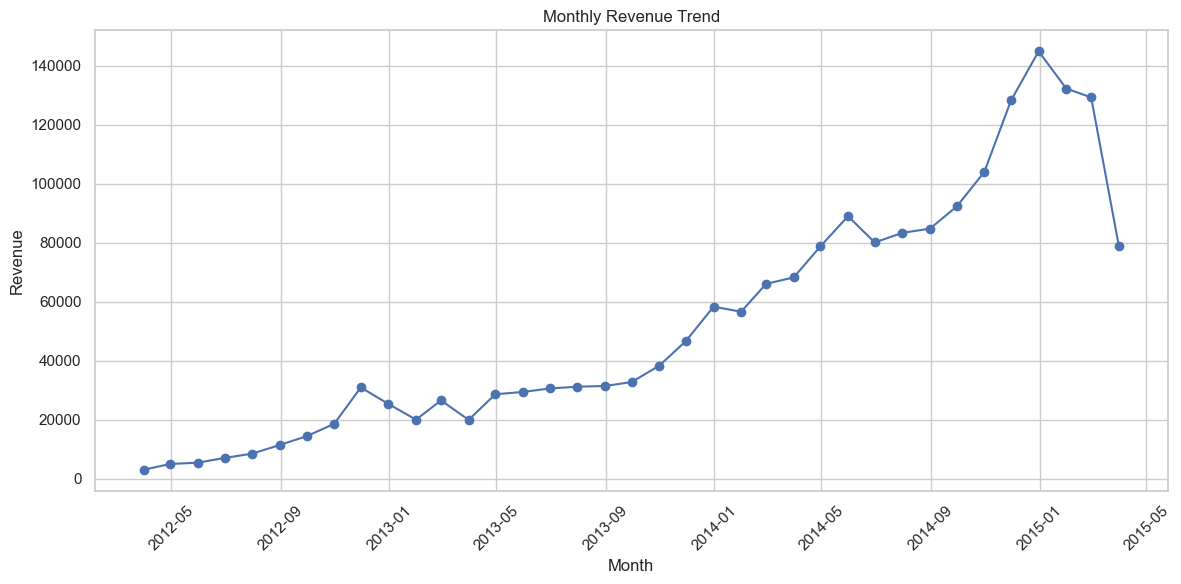

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["created_at"],
    monthly_sales["revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

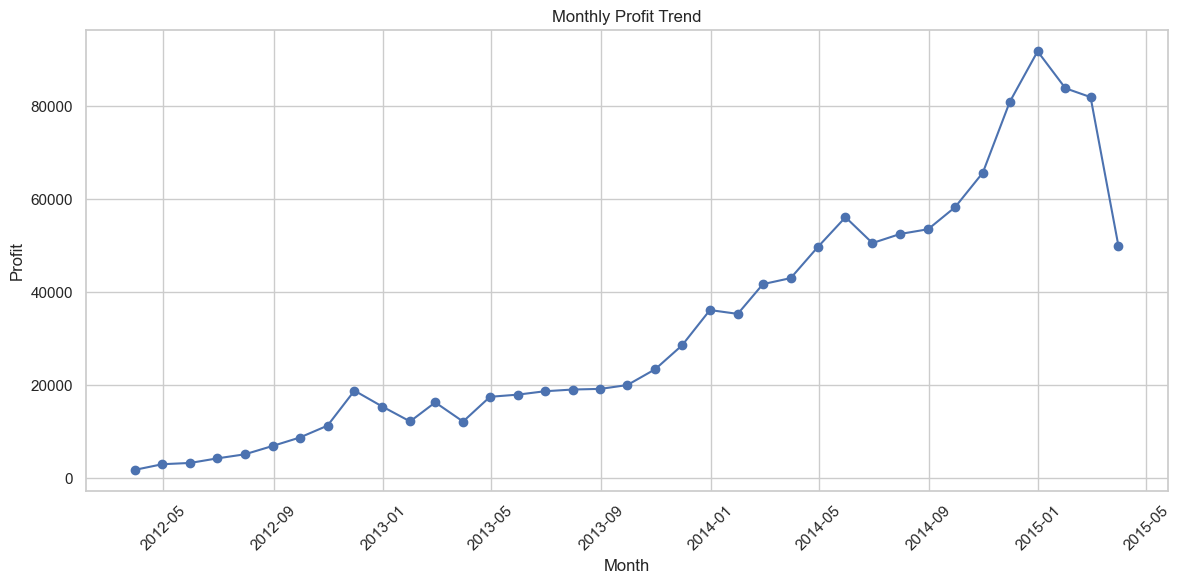

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["created_at"],
    monthly_sales["profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
product_sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)

In [12]:
product_sales["revenue"] = (
    product_sales["price_usd"]
)

product_sales["profit"] = (
    product_sales["price_usd"]
    - product_sales["cogs_usd"]
)

In [13]:
product_summary = (
    product_sales
    .groupby(
        ["product_id", "product_name"]
    )
    .agg(
        units_sold=("order_item_id", "count"),
        revenue=("revenue", "sum"),
        cogs=("cogs_usd", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

In [14]:
product_summary["profit_margin"] = np.where(
    product_summary["revenue"] != 0,
    (
        product_summary["profit"]
        / product_summary["revenue"]
    ) * 100,
    0
)

In [15]:
top_revenue_products = (
    product_summary
    .sort_values(
        "revenue",
        ascending=False
    )
    .head(10)
)

display(top_revenue_products)

,product_id,product_name,units_sold,revenue,cogs,profit,profit_margin
0,1,The Original Mr. Fuzzy,24226,1211057.74,472164.74,738893.0,61.012202
1,2,The Forever Love Bear,5796,347702.04,130352.04,217350.0,62.510418
2,3,The Birthday Sugar Panda,4985,229260.15,72232.65,157027.5,68.493151
3,4,The Hudson River Mini bear,5018,150489.82,47620.82,102869.0,68.356119


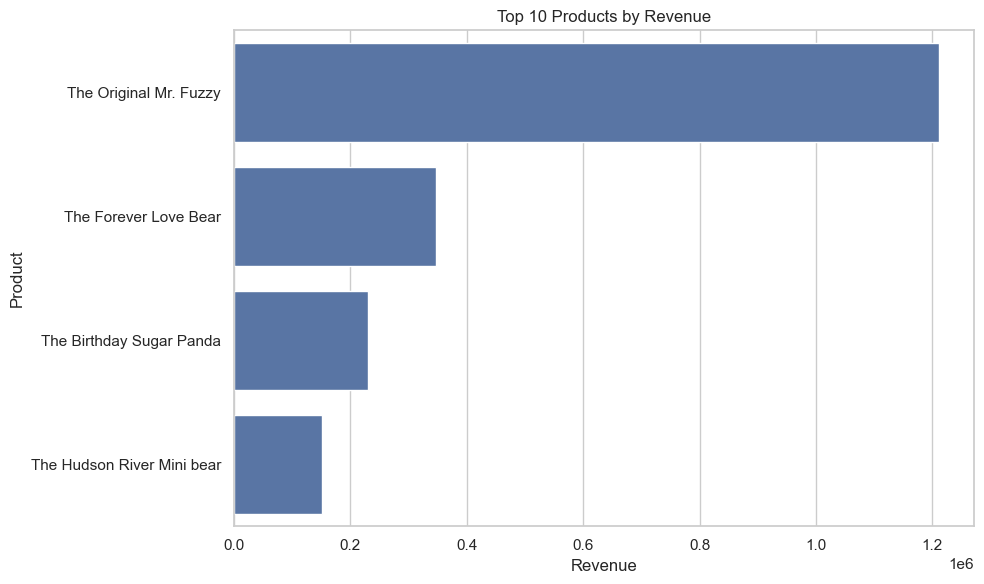

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue_products,
    x="revenue",
    y="product_name"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

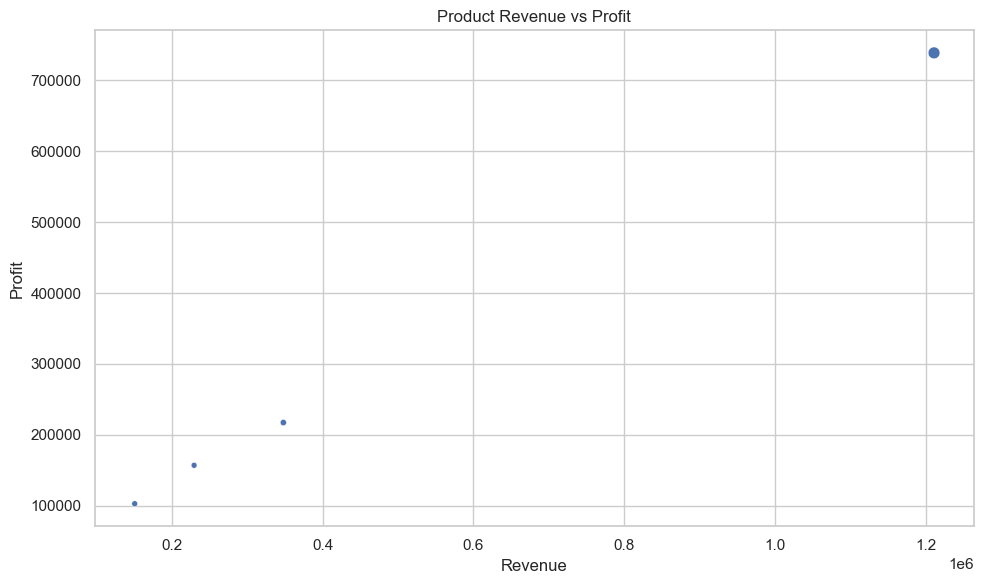

In [17]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_summary,
    x="revenue",
    y="profit",
    size="units_sold",
    legend=False
)

plt.title("Product Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/product_revenue_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
customer_analysis = (
    orders_analysis
    .groupby("user_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_items=("total_items", "sum"),
        total_revenue=("revenue", "sum"),
        total_profit=("profit", "sum")
    )
    .reset_index()
)

In [19]:
customer_analysis["customer_type"] = np.where(
    customer_analysis["total_orders"] == 1,
    "One-time",
    "Repeat"
)

In [20]:
customer_type_count = (
    customer_analysis["customer_type"]
    .value_counts()
)

display(customer_type_count)

customer_type
One-time    31105
Repeat        591
Name: count, dtype: int64

In [21]:
customer_type_revenue = (
    customer_analysis
    .groupby("customer_type")
    ["total_revenue"]
    .sum()
    .reset_index()
)

display(customer_type_revenue)

,customer_type,total_revenue
0,One-time,1864153.31
1,Repeat,74356.44


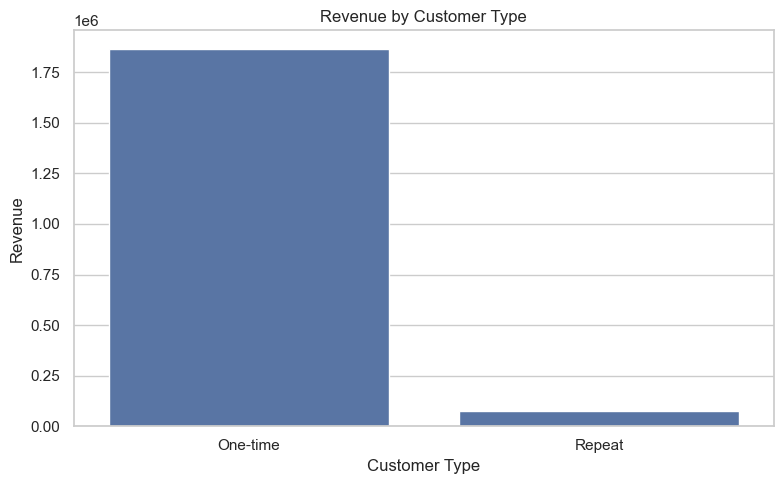

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_type_revenue,
    x="customer_type",
    y="total_revenue"
)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "../visualizations/customer_type_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
top_customers = (
    customer_analysis
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(10)
)

display(top_customers)

,user_id,total_orders,total_items,total_revenue,total_profit,customer_type
26808,341972,3,6,251.94,165.0,Repeat
25167,324814,3,5,245.95,157.5,Repeat
11722,172266,3,5,237.95,155.5,Repeat
20506,275098,3,5,235.95,150.5,Repeat
21062,281298,2,4,219.96,136.0,Repeat
9314,142410,3,4,219.96,136.0,Repeat
24501,317773,2,4,215.96,137.0,Repeat
26264,336150,3,5,209.95,132.5,Repeat
10652,158790,3,4,205.96,130.0,Repeat
23498,307597,2,4,205.96,130.0,Repeat


In [24]:
refund_analysis = refunds.merge(
    order_items[
        [
            "order_item_id",
            "product_id"
        ]
    ],
    on="order_item_id",
    how="left"
)

In [25]:
refund_analysis = refund_analysis.merge(
    products[
        [
            "product_id",
            "product_name"
        ]
    ],
    on="product_id",
    how="left"
)

In [26]:
total_refunds = len(refunds)

total_refund_amount = (
    refunds["refund_amount_usd"].sum()
)

refunded_orders = (
    refunds["order_id"].nunique()
)

refund_rate = (
    refunded_orders
    / total_orders
) * 100

In [27]:
refund_kpis = pd.DataFrame({
    "Metric": [
        "Total Refund Records",
        "Total Refund Amount",
        "Refunded Orders",
        "Refund Rate (%)"
    ],
    "Value": [
        total_refunds,
        total_refund_amount,
        refunded_orders,
        refund_rate
    ]
})

display(refund_kpis)

,Metric,Value
0,Total Refund Records,1731.000000
1,Total Refund Amount,85338.690000
2,Refunded Orders,1723.000000
3,Refund Rate (%),5.332219


In [28]:
product_refunds = (
    refund_analysis
    .groupby("product_name")
    .agg(
        refund_count=(
            "order_item_refund_id",
            "count"
        ),
        refund_amount=(
            "refund_amount_usd",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "refund_amount",
        ascending=False
    )
)

In [29]:
display(
    product_refunds.head(10)
)

,product_name,refund_count,refund_amount
3,The Original Mr. Fuzzy,1237,61837.63
0,The Birthday Sugar Panda,301,13842.99
1,The Forever Love Bear,129,7738.71
2,The Hudson River Mini bear,64,1919.36


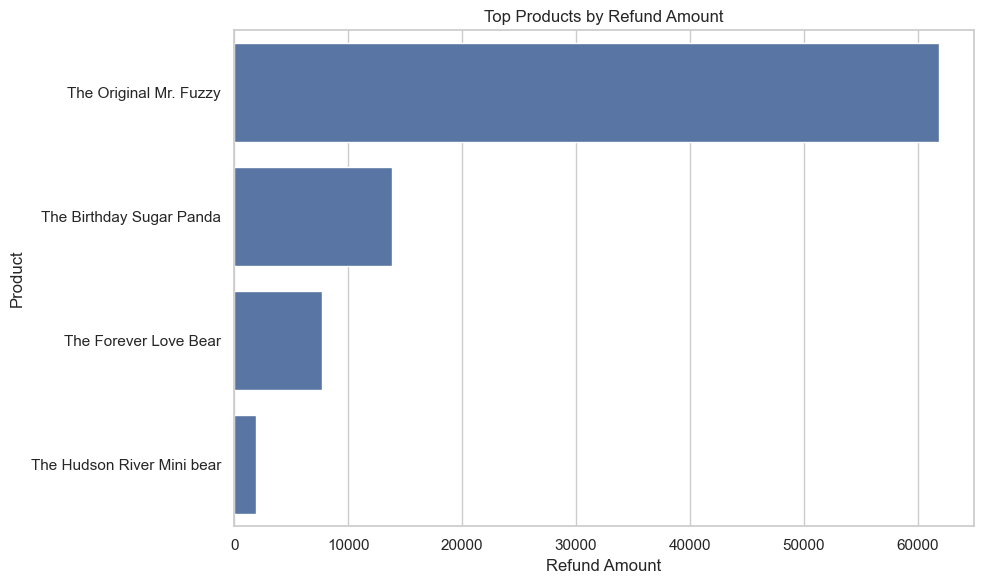

In [30]:
top_refund_products = (
    product_refunds.head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_refund_products,
    x="refund_amount",
    y="product_name"
)

plt.title("Top Products by Refund Amount")
plt.xlabel("Refund Amount")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../visualizations/top_refund_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
product_summary["performance"] = np.select(
    [
        (
            (product_summary["revenue"] >=
             product_summary["revenue"].median())
            &
            (product_summary["profit"] >=
             product_summary["profit"].median())
        ),
        (
            (product_summary["revenue"] >=
             product_summary["revenue"].median())
            &
            (product_summary["profit"] <
             product_summary["profit"].median())
        )
    ],
    [
        "High Revenue - High Profit",
        "High Revenue - Low Profit"
    ],
    default="Other"
)

In [32]:
display(
    product_summary[
        [
            "product_name",
            "revenue",
            "profit",
            "profit_margin",
            "performance"
        ]
    ].sort_values(
        "revenue",
        ascending=False
    )
)

,product_name,revenue,profit,profit_margin,performance
0,The Original Mr. Fuzzy,1211057.74,738893.0,61.012202,High Revenue - High Profit
1,The Forever Love Bear,347702.04,217350.0,62.510418,High Revenue - High Profit
2,The Birthday Sugar Panda,229260.15,157027.5,68.493151,Other
3,The Hudson River Mini bear,150489.82,102869.0,68.356119,Other
